In [1]:
import sys
sys.path.append('/home/ubuntu/data/exp/proj2410')

In [ ]:
import os
import re


from EfficientQAT.quantize.int_linear_real import load_quantized_model


model_path = "/home/ubuntu/data/exp/proj2410/quant_model/Qwen2.5-3B/EfficientQAT/w2gs128"
patterns = r"w(\d+)"


match = re.search(patterns, model_path).group(1)
if match is None:
    wbit = 32
else:
    wbit = int(match)
quant_model,tokenizer = load_quantized_model(model_path,wbit,128)




/home/ubuntu/data/exp/proj2410/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



INFO  ENV: Auto setting PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True' for memory saving.
INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          
Loading quantized model from /home/ubuntu/data/exp/proj2410/quant_model/Qwen2.5-3B/EfficientQAT/w2gs128


100%|██████████| 36/36 [00:00<00:00, 120.25it/s]


OrderedDict({'': 0})
Loading pre-computed quantized weights Successfully


In [4]:
import torch

def get_metrics(data:torch.Tensor):
    # 返回最大值，最小值，中位数，方差
    res= {
        "max": data.max().item(),
        "min": data.min().item(),
        "median": data.median().item(),
        "var": data.var().item()
    }
    return res

In [10]:
from EfficientQAT.quantize.int_linear_real import QuantLinear


data = []


# 检查linear 的scale 数值
for name, module in quant_model.named_modules():
    if isinstance(module, QuantLinear):
        # print(name, get_metrics(module.scales.data))
        layer_idx = int(name.split(".")[2])
        linear_name = ".".join(name.split(".")[-2:])
        data_unit = {"name": linear_name, "layer_idx": layer_idx , **get_metrics(module.scales.data)}
        data.append(data_unit)


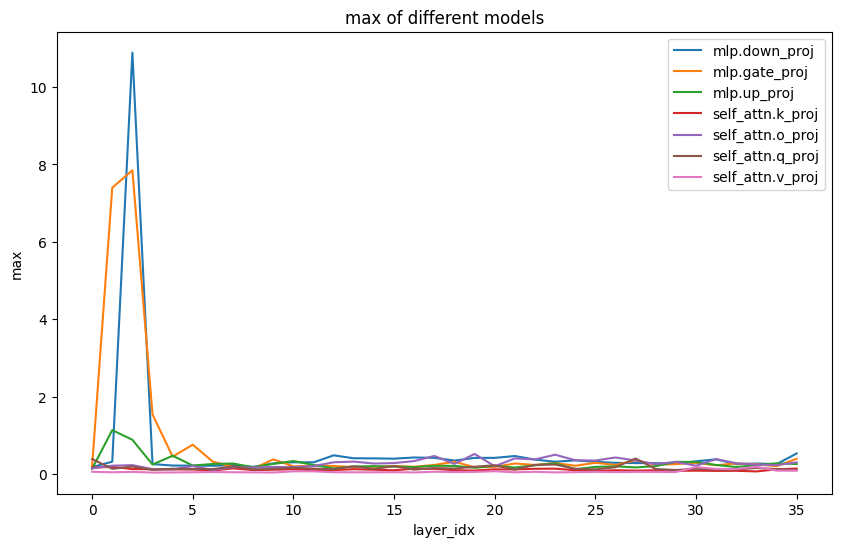

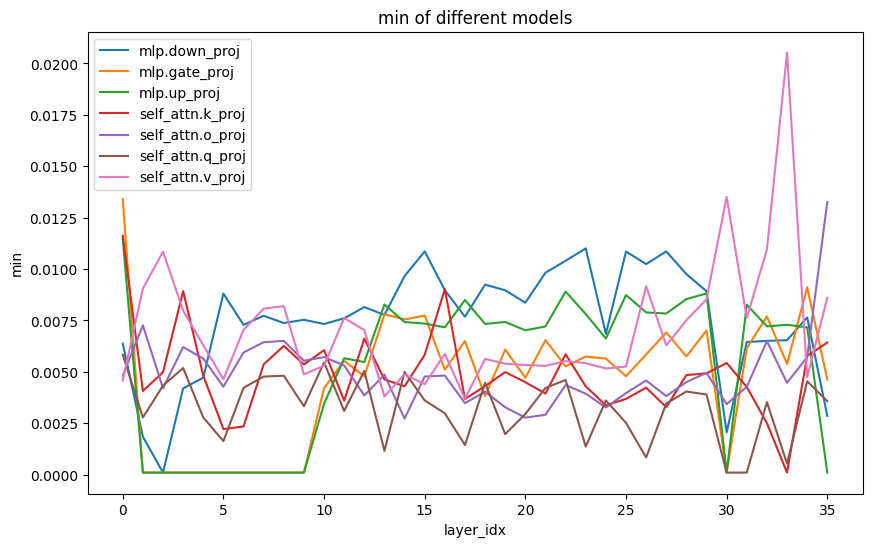

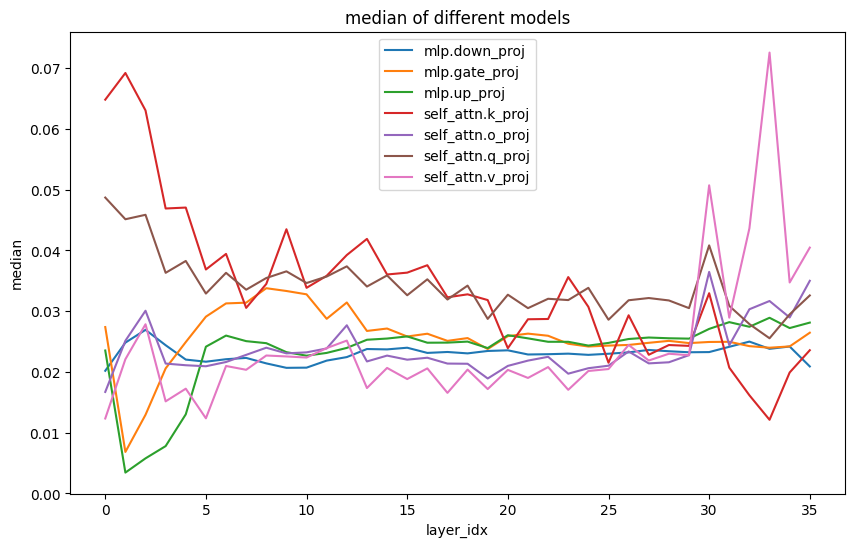

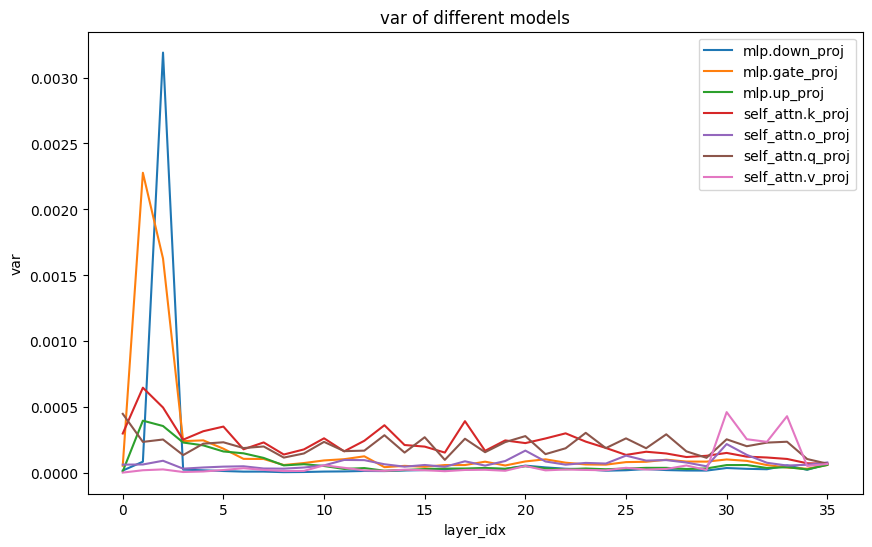

In [34]:
from matplotlib import pyplot as plt
import numpy as np
import torch
import torch.nn as nn
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', 
              '#bcbd22', '#17becf'] 
# 多曲线折线图
def plot_multi_curve(x,y_list,labels,title,xlabel,ylabel,ylim=None,figsize=(10,6)):
    plt.figure(figsize=figsize)
    for i in range(len(y_list)):
        plt.plot(x,y_list[i],
                 color=colors[i],
                 label=labels[i])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if ylim is not None:
        plt.ylim(ylim)
    plt.legend()
    plt.show()

# for to_filter_name in name_list:
#     data_filter_name = filter(lambda x: x['name']==to_filter_name, data)

name_list = np.unique([it["name"] for it in data])
sub_attr = ["max", "min", "median", "var"]

for attr in sub_attr:
    x = np.arange(36)
    y_list = []
    for to_filter_name in name_list:
        data_filter_name = list(filter(lambda x: x['name']==to_filter_name, data))
        y_list.append([it[attr] for it in data_filter_name])
    labels = name_list
    title = f"{attr} of different models"
    xlabel = "layer_idx"
    ylabel = attr
    ylim = None
    
    plot_multi_curve(x,y_list,labels,title,xlabel,ylabel,ylim)
